# **Config & Import**

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, json
from dotenv import load_dotenv

# Import cac ham pipeline tu module chung
from histogram_utils import (
    preprocess_image,
    compute_hsv_histogram,
    normalize_l2,
    extract_histogram_vector,
    cosine_similarity,
    search_similar,
    TARGET_SIZE, HIST_BINS, HIST_RANGES, TABLE_NAME,
)

In [14]:
load_dotenv()

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == 'services':
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == 'src':
    PROJECT_ROOT = PROJECT_ROOT.parent

KEYFRAME_DIR = PROJECT_ROOT / os.getenv('KEYFRAME_DIR', 'public/keyframes')
QUERY_DIR = PROJECT_ROOT / 'public' / 'test_queries'

for f in KEYFRAME_DIR.rglob('*.jpg'):
    print(f)
    

D:\private\multimedia database system\public\keyframes\elephant_test_frame_0.jpg
D:\private\multimedia database system\public\keyframes\elephant_test_frame_1.jpg
D:\private\multimedia database system\public\keyframes\elephant_test_frame_2.jpg
D:\private\multimedia database system\public\keyframes\elephant_test_frame_3.jpg
D:\private\multimedia database system\public\keyframes\lion_test_frame_0.jpg
D:\private\multimedia database system\public\keyframes\lion_test_frame_1.jpg
D:\private\multimedia database system\public\keyframes\lion_test_frame_2.jpg
D:\private\multimedia database system\public\keyframes\lion_test_frame_3.jpg
D:\private\multimedia database system\public\keyframes\parrot_test_frame_0.jpg
D:\private\multimedia database system\public\keyframes\parrot_test_frame_1.jpg
D:\private\multimedia database system\public\keyframes\parrot_test_frame_2.jpg
D:\private\multimedia database system\public\keyframes\parrot_test_frame_3.jpg


# **I. Tien xu ly va Chuyen doi khong gian mau**

## **1A. Chuyen sang HSV (Hue, Saturation, Value):**
    1. Hue (Mau sac):
    2. Saturation (Do bao hoa): Do dam nhat cua mau.
    3. Value (Gia tri): Do sang.

### **Lay 1 anh mau de demo**

In [15]:
sample_image_path = None
for img_file in KEYFRAME_DIR.rglob('*.jpg'):
    sample_image_path = str(img_file)
    break

if sample_image_path is None:
    sample_image_path = 'sample_frame.jpg'
    dummy = np.random.randint(0, 256, (480, 640, 3), dtype=np.uint8)
    cv2.imwrite(sample_image_path, dummy)
    print('Chua co keyframe, dung anh mau ngau nhien.')

print(f'Anh mau: {sample_image_path}')

Anh mau: D:\private\multimedia database system\public\keyframes\elephant_test_frame_0.jpg


### *Doc anh (BGR) va chuyen sang HSV*

Su dung ham `preprocess_image()` tu `histogram_utils.py`

In [16]:
# Doc anh BGR
image_bgr = cv2.imread(sample_image_path)

# Goi ham preprocess_image tu histogram_utils
image_preprocessed = preprocess_image(image_bgr, TARGET_SIZE)

print(f'Kich thuoc anh goc (BGR): {image_bgr.shape}')
print(f'Kich thuoc anh HSV (sau resize {TARGET_SIZE}): {image_preprocessed.shape}')
print(f'  - Hue   range: [{image_preprocessed[:,:,0].min()}, {image_preprocessed[:,:,0].max()}]  (0-179 trong OpenCV)')
print(f'  - Sat   range: [{image_preprocessed[:,:,1].min()}, {image_preprocessed[:,:,1].max()}]  (0-255)')
print(f'  - Value range: [{image_preprocessed[:,:,2].min()}, {image_preprocessed[:,:,2].max()}]  (0-255)')

Kich thuoc anh goc (BGR): (720, 1280, 3)
Kich thuoc anh HSV (sau resize (224, 224)): (224, 224, 3)
  - Hue   range: [0, 178]  (0-179 trong OpenCV)
  - Sat   range: [0, 252]  (0-255)
  - Value range: [10, 248]  (0-255)


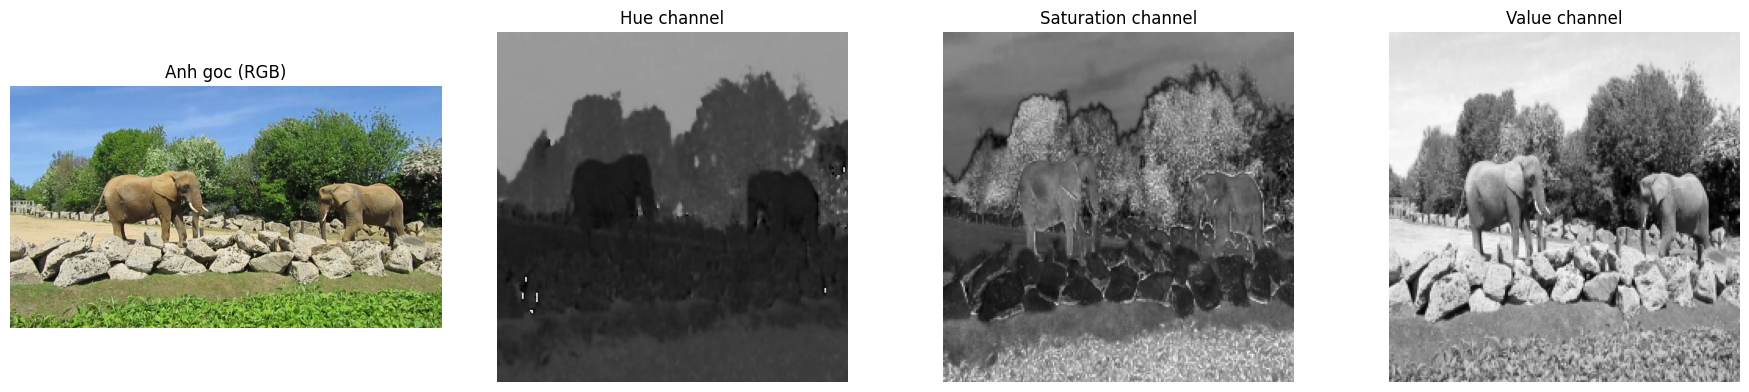

In [17]:
# Truc quan hoa: BGR goc vs HSV
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(image_rgb)
axes[0].set_title('Anh goc (RGB)')

for i, (ch, name) in enumerate(zip([0,1,2], ['Hue','Saturation','Value'])):
    axes[i+1].imshow(image_preprocessed[:,:,ch], cmap='gray')
    axes[i+1].set_title(f'{name} channel')

for ax in axes:
    ax.axis('off')
plt.tight_layout(); plt.show()

# **II. Tính Histogram (Binning)**

* **H** : 16, **S** : 4, **V** : 4
* => có 16 * 4 * 4 = 256 thùng
* **Su dung ham `compute_hsv_histogram()` tu `histogram_utils.py`**

So bins: H=8, S=2, V=2
Tong to hop (chieu vector): 8*2*2 = 32
Tong pixel : 50176
Tong dem   : 50176 (phai = tong pixel)

Histogram vector (raw):
[2.3260e+03 5.7910e+03 3.1200e+02 4.4000e+01 4.3090e+03 1.1514e+04
 2.3950e+03 3.9980e+03 3.7410e+03 9.1600e+02 2.4270e+03 3.2000e+02
 2.3300e+02 2.9200e+02 0.0000e+00 0.0000e+00 7.4000e+01 1.0185e+04
 0.0000e+00 1.2710e+03 3.0000e+00 3.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 2.2000e+01 0.0000e+00
 0.0000e+00 0.0000e+00]


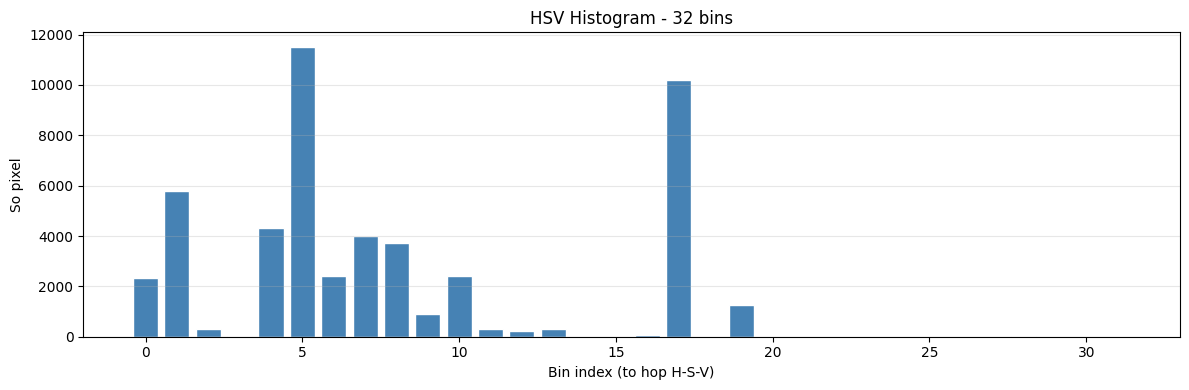

In [18]:
hist_vector = compute_hsv_histogram(image_preprocessed)
total_pixels = image_preprocessed.shape[0] * image_preprocessed.shape[1]

print(f'So bins: H={HIST_BINS[0]}, S={HIST_BINS[1]}, V={HIST_BINS[2]}')
print(f'Tong to hop (chieu vector): {HIST_BINS[0]}*{HIST_BINS[1]}*{HIST_BINS[2]} = {hist_vector.shape[0]}')
print(f'Tong pixel : {total_pixels}')
print(f'Tong dem   : {hist_vector.sum():.0f} (phai = tong pixel)')
print(f'\nHistogram vector (raw):\n{hist_vector}')

# Ve bieu do thanh
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(hist_vector)), hist_vector, color='steelblue', edgecolor='white')
ax.set_xlabel('Bin index (to hop H-S-V)')
ax.set_ylabel('So pixel')
ax.set_title(f'HSV Histogram - {len(hist_vector)} bins')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# **III. Chuan hoa Vector (Normalization)**

Neu mot anh to va mot anh nho co cung noi dung, anh to se co so luong pixel lon hon, lam cho gia tri trong cac "thung" cao hon han.
 * **Giai phap**: Chia gia tri cua moi thung cho tong so pixel trong anh.
 * **Cong cu**: Su dung cong thuc chuan hoa $L2$ de dua do dai vector ve 1:
                $$v_{normalized} = \frac{v}{\|v\|_2}$$
 * **Ket qua**: Ban nhan duoc mot day so (Vector) ma tong cac phan tu hoac do dai hinh hoc cua no la mot hang so.

Su dung ham `normalize_l2()` tu `histogram_utils.py`

In [ ]:
# Goi ham normalize_l2 tu histogram_utils
hist_normalized = normalize_l2(hist_vector)

print('=== So sanh truoc va sau chuan hoa L2 ===')
print(f'Truoc: ||v||_2 = {np.linalg.norm(hist_vector):.4f}')
print(f'Sau  : ||v||_2 = {np.linalg.norm(hist_normalized):.4f}  (phai = 1.0)')
print(f'\nVector truoc chuan hoa (raw counts):\n  {hist_vector}')
print(f'\nVector sau chuan hoa L2:\n  {hist_normalized}')

# Ve so sanh
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.bar(range(len(hist_vector)), hist_vector, color='coral', edgecolor='white')
ax1.set_title('Truoc chuan hoa')
ax1.set_xlabel('Bin'); ax1.set_ylabel('So pixel'); ax1.grid(axis='y', alpha=0.3)

ax2.bar(range(len(hist_normalized)), hist_normalized, color='mediumseagreen', edgecolor='white')
ax2.set_title('Sau chuan hoa L2')
ax2.set_xlabel('Bin'); ax2.set_ylabel('Gia tri'); ax2.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### Pipeline hoan chinh

Su dung ham `extract_histogram_vector()` tu `histogram_utils.py` — gom tat ca cac buoc tren.

In [ ]:
# Goi ham extract_histogram_vector tu histogram_utils
test_vec = extract_histogram_vector(sample_image_path)
print(f'Pipeline OK - vector {test_vec.shape[0]} chieu, ||v||_2 = {np.linalg.norm(test_vec):.4f}')

# IV. Luu tru vao Co so du lieu Vector (Indexing)

**Mapping**: Moi dong trong database se bao gom: [Vector] | [Video_ID] | [Timestamp].

In [ ]:
# --- Buoc 4: Luu vector vao Supabase (pgvector) ---
from supabase import create_client, Client

SUPABASE_URL = os.getenv('SUPABASE_URL')
SUPABASE_KEY = os.getenv('SUPABASE_KEY')
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

# ---- Ham insert vector ----
def insert_feature_vector(supabase_client: Client,
                          table: str,
                          video_id: str,
                          timestamp: float,
                          vector: np.ndarray,
                          frame_path: str = None) -> dict:
    row = {
        'video_id': video_id,
        'timestamp': timestamp,
        'feature_vector': vector.tolist(),
    }
    if frame_path:
        row['frame_path'] = frame_path

    response = supabase_client.table(table).insert(row).execute()
    return response

# ---- Batch: xu ly tat ca keyframe va insert ----
inserted = 0
errors = 0

for img_path in sorted(KEYFRAME_DIR.rglob('*.jpg')):
    try:
        parts = img_path.stem.rsplit('_frame_', maxsplit=1)
        video_id = parts[0] if len(parts) == 2 else img_path.stem
        frame_idx = int(parts[1]) if len(parts) == 2 else 0
        timestamp = frame_idx

        vec = extract_histogram_vector(str(img_path))
        insert_feature_vector(supabase, TABLE_NAME, video_id, timestamp, vec, str(img_path))
        inserted += 1
        print(f'  OK: {img_path.name}')
    except Exception as e:
        errors += 1
        print(f'  ERROR: {img_path.name}: {e}')

print(f'\n=== Ket qua ===')
print(f'Da insert : {inserted} vectors')
print(f'Loi       : {errors}')
print(f'Vector dim : {HIST_BINS[0]*HIST_BINS[1]*HIST_BINS[2]}')
print(f'Table      : {TABLE_NAME}')

# V. Kiem tra du lieu da luu (Verification)

In [ ]:
# --- Doc tat ca vector da luu trong Supabase ---
response = supabase.table(TABLE_NAME).select('*').execute()
db_rows = response.data
print(f'So dong trong bang {TABLE_NAME}: {len(db_rows)}')

for row in db_rows[:3]:
    vid = row.get('video_id', '?')
    ts  = row.get('timestamp', '?')
    vec_len = len(row.get('feature_vector', []))
    fp  = row.get('frame_path', '?')
    print(f'  video_id={vid}, timestamp={ts}, vector_dim={vec_len}, path={fp}')

In [ ]:
# --- So sanh vector DB vs vector tinh lai local ---
print('=== So sanh vector DB vs Local ===')
mismatch_count = 0
match_count = 0

for row in db_rows:
    frame_path = row.get('frame_path', '')
    if not frame_path or not Path(frame_path).exists():
        continue
    
    vec_db = np.array(row['feature_vector'], dtype=np.float64)
    vec_local = extract_histogram_vector(frame_path)
    
    cos_sim = cosine_similarity(vec_db, vec_local)
    diff = np.max(np.abs(vec_db - vec_local))
    
    name = Path(frame_path).name
    if cos_sim > 0.9999 and diff < 1e-6:
        match_count += 1
    else:
        mismatch_count += 1
        print(f'  [MISMATCH] {name}: cosine={cos_sim:.6f}, max_diff={diff:.8f}')

print(f'\nKet qua: {match_count} MATCH, {mismatch_count} MISMATCH')
if mismatch_count == 0:
    print('>>> TAT CA VECTOR DA LUU CHINH XAC!')
else:
    print('>>> CO SAI LECH - kiem tra lai pipeline hoac precision.')

## 5B. Test tim kiem tuong dong (Similarity Search)

In [ ]:
# --- Test similarity search ---
query_images = sorted(QUERY_DIR.glob('query_*.jpg'))

if not query_images:
    print(f'Khong tim thay anh query trong {QUERY_DIR}')
    print('Chay: python src/services/generate_test_keyframes.py')
else:
    print(f'Tim thay {len(query_images)} anh query\n')
    total_correct = 0
    total_queries = 0
    
    for qpath in query_images:
        species = qpath.stem.replace('query_', '')
        query_vec = extract_histogram_vector(str(qpath))
        results = search_similar(query_vec, db_rows, top_k=5)
        
        top1_vid = results[0]['video_id']
        is_correct = species in top1_vid
        status = 'PASS' if is_correct else 'FAIL'
        if is_correct:
            total_correct += 1
        total_queries += 1
        
        print(f'[{status}] Query: {qpath.name} (loai: {species})')
        for rank, r in enumerate(results, 1):
            vid = r['video_id']
            sim = r['similarity']
            match_marker = ' <-- SAME' if species in vid else ''
            print(f'  #{rank}  {vid:30s}  sim={sim:.4f}{match_marker}')
        print()
    
    print('=' * 50)
    print(f'Top-1 Accuracy: {total_correct}/{total_queries}')
    if total_correct == total_queries:
        print('>>> TAT CA QUERY DEU DUNG!')
    else:
        print('>>> Mot so query sai.')

## 5C. Truc quan hoa ket qua tim kiem

In [ ]:
if query_images:
    n_queries = len(query_images)
    fig, axes = plt.subplots(n_queries, 4, figsize=(16, 4 * n_queries))
    if n_queries == 1:
        axes = [axes]
    
    for i, qpath in enumerate(query_images):
        species = qpath.stem.replace('query_', '')
        query_vec = extract_histogram_vector(str(qpath))
        results = search_similar(query_vec, db_rows, top_k=3)
        
        q_img = cv2.cvtColor(cv2.imread(str(qpath)), cv2.COLOR_BGR2RGB)
        axes[i][0].imshow(q_img)
        axes[i][0].set_title(f'QUERY: {species}', fontsize=10, fontweight='bold')
        axes[i][0].axis('off')
        
        for j, r in enumerate(results):
            fp = r['frame_path']
            if Path(fp).exists():
                r_img = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2RGB)
                axes[i][j+1].imshow(r_img)
            vid = r['video_id']
            sim = r['similarity']
            color = 'green' if species in vid else 'red'
            axes[i][j+1].set_title(f'#{j+1}: {vid}\nsim={sim:.4f}', fontsize=9, color=color)
            axes[i][j+1].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Ket qua Histogram Similarity Search', fontsize=14, fontweight='bold', y=1.01)
    plt.show()
    print('Xanh = dung loai | Do = sai loai')